In [1]:
# ============================
# 1. GOOGLE DRIVE MOUNT
# ============================

#Import the Drive module provided by Colab to interact with Google Drive.
from google.colab import drive

#Mount Google Drive in the local directory /content/drive.
#force_remount=True forces a remount even if it was already mounted.
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
# =========================================
# 2. GLOBAL CONFIG + IMPORTS & DEVICE
# =========================================

#Dictionary of global hyperparameters and constants.
global_var = {
    # DATA LOADING / PREPROCESSING PARAMETERS:
    "batch_size": 128,        #Samples per batch (increased for A100).
    "n_workers": 2,           #DataLoader workers for prefetching/parallel loading.
    "max_seq_len": 512,       #Maximum length; long texts are truncated, short ones padded.

    # MODEL PARAMETERS (TextCNN):
    "embedding_dim": 300,             #Embedding dimension.
    "cnn_num_filters": 400,           #Number of filters per convolution branch.
    "cnn_kernel_sizes": [3, 4, 5, 7], #Multiple kernels (including 7 for longer contexts).
    "mlp_hidden_dim": 400,            #Hidden MLP layer size.
    "output_dim": 2,                  #Classes: 0 = HUMAN, 1 = GenAI.
    "dropout": 0.25,                  #Dropout for regularization.

    # TRAINING PARAMETERS:
    "learning_rate": 1e-3,            #Smaller LR for more stable training.
    "epochs": 10,                     #Maximum number of epochs (with early stopping).
    "weight_decay": 1e-5,             #L2 penalty.
    "label_smoothing": 0.0,           #Label smoothing for CrossEntropy.

    # VALIDATION / EARLY STOP:
    "val_size": 0.2,                  #(In the current setup we do not split train: we directly use DEV as VAL.)
    "patience": 5,                    #Early stopping if it does not improve for N epochs.

    # GLOBAL CONTROL OF THE DECISION THRESHOLD:
    # - If None  → use the threshold optimized on VALIDATION (grid search).
    # - If float → global override (e.g., 0.35 for dtEN, 0.40 for ART&MH, etc.).
    # CHANGE ONLY HERE TO MODIFY THE DECISION THRESHOLD.
    "DECISION_THRESHOLD_OVERRIDE": None
}

# --------------------
# STANDARD IMPORTS
# --------------------
import os
import math
import copy
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

# --------------------
# PYTORCH IMPORTS
# --------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.amp import autocast, GradScaler

# --------------------
# SCIKIT-LEARN IMPORTS
# --------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# --------------------
# DEVICE SELECTION (CPU / GPU, preferring A100 if available)
# --------------------
if torch.cuda.is_available():
    device_name = torch.cuda.get_device_name(0)              #Name of the first available GPU.
    if "A100" in device_name:
        device = torch.device("cuda:0")                      #If we detect an A100, use it.
        print(f"[LOG] A100 GPU detected and selected: {device_name} ({device})")
    else:
        device = torch.device("cuda:0")                      #Otherwise, still use the first CUDA device.
        print(f"[LOG] CUDA GPU detected (not A100): {device_name} ({device})")
else:
    device = torch.device("cpu")                             #CPU fallback.
    print(f"[LOG] No CUDA GPU available. Selected device → {device}")

[LOG] A100 GPU detected and selected: NVIDIA A100-SXM4-40GB (cuda:0)


In [3]:
# =========================================
# 3. UTILITIES: COLLATE, TOKENIZER, VOCAB, DATASET, SEED
# =========================================

#Reserved special tokens: <pad> (id 0) and <unk> (id 1).
PAD, UNK = "<pad>", "<unk>"

#Regex to tokenize alphanumeric (Unicode) words while ignoring punctuation.
_token_re = re.compile(r"\b\w+\b", flags=re.UNICODE)

def basic_tokenizer(text: str):
    """
    Minimal regex-based tokenization:
    - lowercases the input
    - extracts alphanumeric sequences as tokens
    """
    return _token_re.findall(str(text).lower())

def build_vocab(text_iter, min_freq: int = 1):
    """
    Builds a vocabulary from an iterable of texts.
    - text_iter: iterable of strings (one per line / document)
    - min_freq: minimum frequency for a token to be included in the vocabulary
    """
    counter = Counter()                     #Multiset of token frequencies.
    for line in text_iter:                  #Single pass over all texts.
        counter.update(basic_tokenizer(line))

    #Initialize the vocabulary with PAD (0) and UNK (1).
    vocab = {PAD: 0, UNK: 1}
    for tok, c in counter.most_common():    #Add tokens in descending frequency order.
        if c >= min_freq:                   #Filter out very rare tokens.
            vocab[tok] = len(vocab)         #Assign a new incremental ID.
    return vocab

def collate_trim(batch):
    """
    Custom collate function for NLP with padded sequences.
    Input: list of tuples (x: tensor [T_max], y: int)

    - Computes the true length of each sequence (counting tokens != 0).
    - Trims all sequences in the batch to the maximum true length L_batch.
    - Returns:
        xs_trim: tensor [B, L_batch]
        ys:      tensor [B]
    """
    #Unzip the batch into lists of tensors (xs) and labels (ys).
    xs, ys = zip(*batch)

    #True lengths for each sequence (number of tokens != PAD).
    lens = [int((x != 0).sum().item()) for x in xs]

    #Maximum true length in the batch (at least 1).
    Lb = max(1, max(lens)) if lens else 1

    #Dynamically trim each sequence to length Lb.
    xs_trim = torch.stack([x[:Lb] for x in xs])

    #Stack labels into a single tensor [B].
    ys = torch.stack(ys)
    return xs_trim, ys

def make_loader(dataset, batch_size, shuffle):
    """
    Builds a DataLoader with:
      - collate_fn = collate_trim (batch-level dynamic padding)
      - pin_memory for faster GPU transfers (if CUDA device)
      - persistent_workers + prefetch_factor if n_workers > 0
    """
    kwargs = {}
    if global_var["n_workers"] > 0:
        kwargs["persistent_workers"] = True     #Keep workers alive across epochs.
        kwargs["prefetch_factor"] = 4           #Number of prefetched batches per worker.

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=global_var["n_workers"],
        pin_memory=(device.type == "cuda"),
        collate_fn=collate_trim,
        **kwargs
    )

class TextDataset(Dataset):
    """
    Minimal PyTorch-style text dataset.

    Requires a CSV with at least:
      - 'text' column
      - 'label' column
    """
    def __init__(self, csv_path: str, vocab: dict | None = None, min_freq: int = 1):
        #Load the CSV into a DataFrame.
        df = pd.read_csv(csv_path)

        #Extract the 'text' column as a list of strings.
        self.texts  = df["text"].astype(str).tolist()

        #Extract the 'label' column as a list of integers.
        self.labels = df["label"].astype(int).tolist()

        #If an external vocabulary is provided, use it; otherwise build from scratch on these texts.
        self.vocab  = vocab or build_vocab(self.texts, min_freq = 5)

    def __len__(self):
        #Return the number of samples in the dataset.
        return len(self.labels)

    def encode(self, text: str):
        """
        Converts a string into a tensor of token IDs:
          1) Tokenize in lowercase with basic_tokenizer.
          2) Map each token to an id (UNK if not present in vocab).
          3) Truncate to max_seq_len.
          4) Pad with PAD up to max_seq_len.
        """
        #Tokenization + token→id mapping, with UNK fallback.
        ids = [self.vocab.get(t, self.vocab[UNK])
               for t in basic_tokenizer(text)][: global_var["max_seq_len"]]

        #Pad up to the fixed length max_seq_len.
        ids += [self.vocab[PAD]] * (global_var["max_seq_len"] - len(ids))

        #Return a long tensor of shape [T].
        return torch.tensor(ids, dtype=torch.long)

    def __getitem__(self, idx):
        """
        Returns the pair (input_ids, label) for the given index idx.
        """
        return self.encode(self.texts[idx]), torch.tensor(self.labels[idx])

# --------------------
# SEEDING FOR REPRODUCIBILITY
# --------------------
def seed_everything(seed=42):
    """
    Sets the seeds for:
      - Python random
      - NumPy
      - PyTorch (CPU and CUDA)
    and forces cuDNN into deterministic mode for reproducible results.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#Apply the initial seed.
seed_everything(42)

In [4]:
# ==============================================================
# 4. DATA LOADING, TRAIN / VAL / TEST CREATION, DATASETS & LOADERS
# ==============================================================

#Base Drive path where the CSVs are stored (adjust if different).
# ------------------ CHANGE THE PATH ------------------
BASE = "/content/drive/MyDrive/TESI-Classificazione/MIO"

#Paths of the original datasets (full TRAIN and full DEV).
TRAIN_CSV_ORIG = f"{BASE}/en_train_full.csv"   #Used for training + vocab.
DEV_CSV_ORIG   = f"{BASE}/en_dev_full.csv"     #Used to extract VAL and TEST(60 IDs).

import tempfile  #To create temporary files compatible with TextDataset.

#Load the raw DataFrames.
df_train = pd.read_csv(TRAIN_CSV_ORIG)
df_dev   = pd.read_csv(DEV_CSV_ORIG)

#===== TRAIN BALANCING (downsampling the majority class) =====
#0 = HUMAN, 1 = GenAI.
n_h = (df_train["label"] == 0).sum()
n_g = (df_train["label"] == 1).sum()
print("[BEFORE BALANCE] HUMAN:", n_h, "GenAI:", n_g)

#Minimum count to balance.
n_min = min(n_h, n_g)

#Sample n_min examples per class.
df_h_bal = df_train[df_train["label"] == 0].sample(n_min, random_state=42)
df_g_bal = df_train[df_train["label"] == 1].sample(n_min, random_state=42)

#Merge and shuffle.
df_train = pd.concat([df_h_bal, df_g_bal], axis=0)\
             .sample(frac=1, random_state=42)\
             .reset_index(drop=True)

print("[AFTER BALANCE] HUMAN:", (df_train["label"] == 0).sum(),
      "GenAI:", (df_train["label"] == 1).sum())
print("[AFTER BALANCE] TRAIN rows =", len(df_train))
# ===== END BALANCING =====


#List of the 60 IDs to be used as TEST (as specified).
# ------------------ CHANGE THE ID, IF YOU WANT DISCOVER OTHER RESULTS ------------------
TEST_IDS = [
    1785,6558,6958,7814,8393,22792,24314,24563,25355,26795,26870,29186,36581,40760,
    41855,52126,56445,57316,57790,58514,60992,64197,69344,72099,72844,72926,88238,
    89196,90169,94106,99598,109977,110606,110787,117759,132477,142851,142966,147127,
    154474,154796,157817,158265,167622,170365,177393,183015,183849,187702,193068,
    194164,194395,198917,200148,211244,212189,222169,227883,233881,250929
]
#Remove potential duplicates while preserving order.
TEST_IDS = list(dict.fromkeys(TEST_IDS))

def pick_test_rows_from_dev(df_dev, ids):
    """
    Select rows from df_dev corresponding to the given list of IDs:
      1) Try using the 'id' column (as-is or cast to numeric).
      2) Otherwise fall back to row indices (0-based or 1-based).
    Returns:
      - df_test_sel: DataFrame containing the TEST rows
      - used_idx: original indices used
      - how: description of the method used
    """
    #1) If an 'id' column exists, try direct matching on 'id'.
    if "id" in df_dev.columns:
        m = df_dev["id"].isin(ids)
        if m.sum() < len(ids):
            #If not all are found, try casting 'id' to numeric and retry.
            try:
                m = m | pd.to_numeric(df_dev["id"], errors="coerce").isin(ids)
            except Exception:
                pass
        if int(m.sum()) > 0:
            return df_dev.loc[m].copy(), df_dev.index[m], "by id"

    #2) Fallback to row indices (0-based / 1-based).
    m0 = df_dev.index.isin(ids)
    m1 = df_dev.index.isin([i - 1 for i in ids])  #Hypothesis: ids are 1-based.

    if int(m0.sum()) >= int(m1.sum()):
        return df_dev.loc[m0].copy(), df_dev.index[m0], "by 0-based row index"
    else:
        return df_dev.loc[m1].copy(), df_dev.index[m1], "by 1-based row index (id-1)"

#Apply TEST selection using the 60 IDs.
df_test_sel, used_idx, how = pick_test_rows_from_dev(df_dev, TEST_IDS)
assert len(df_test_sel) > 0, "No rows selected for the TEST (check the IDs)."

#df_test = DEV subset for the 60 IDs; df_val = remaining DEV.
df_test = df_test_sel.reset_index(drop=True)
df_val  = df_dev.drop(used_idx).reset_index(drop=True)

print(f"[LOG] TEST selection mode: {how}")
print(f"[CHECK] TRAIN rows = {len(df_train)}")
print(f"[CHECK] DEV rows   = {len(df_dev)}")
print(f"[CHECK] VAL rows   = {len(df_val)}")
print(f"[CHECK] TEST rows  = {len(df_test)}")

#Save DataFrames into temporary CSVs (compatible with TextDataset).
with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp_train_file:
    df_train.to_csv(tmp_train_file.name, index=False)
    TRAIN_CSV = tmp_train_file.name   #Temporary path for TRAIN.

with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp_val_file:
    df_val.to_csv(tmp_val_file.name, index=False)
    EVAL_CSV = tmp_val_file.name     #Temporary path for VALIDATION.

with tempfile.NamedTemporaryFile(suffix=".csv", delete=False) as tmp_test_file:
    df_test.to_csv(tmp_test_file.name, index=False)
    TEST_CSV = tmp_test_file.name    #Temporary path for TEST(60).

#1) Vocabulary ONLY on TRAIN (avoids leakage from VAL/TEST).
full_train = TextDataset(TRAIN_CSV, min_freq=3)
vocab = full_train.vocab
print(f"[LOG] Vocabulary size (from TRAIN): {len(vocab)}")

#2) VALIDATION and TEST datasets reusing the TRAIN vocabulary.
eval_dataset = TextDataset(EVAL_CSV, vocab=vocab)
test_dataset = TextDataset(TEST_CSV, vocab=vocab)

#3) DataLoaders for TRAIN / VAL / TEST.
train_loader = make_loader(full_train,   global_var["batch_size"], shuffle=True)
val_loader   = make_loader(eval_dataset, global_var["batch_size"], shuffle=False)
test_loader  = make_loader(test_dataset, global_var["batch_size"], shuffle=False)

#Sanity check dataset sizes.
assert len(eval_dataset) == len(df_val),  f"I expect {len(df_val)} in VALIDATION"
assert len(test_dataset) == len(df_test), f"I expect {len(df_test)} in TEST"

print(f"[CHECK] VALIDATION rows (loader) = {len(eval_dataset)}")
print(f"[CHECK] TEST rows (loader)       = {len(test_dataset)}")

#Keep a reusable base_vocab variable for evaluation.
base_vocab = vocab

[BEFORE BALANCE] HUMAN: 229209 GenAI: 381467
[AFTER BALANCE] HUMAN: 229209 GenAI: 229209
[AFTER BALANCE] TRAIN rows = 458418
[LOG] TEST selection mode: by 0-based row index
[CHECK] TRAIN rows = 458418
[CHECK] DEV rows   = 261849
[CHECK] VAL rows   = 261789
[CHECK] TEST rows  = 60
[LOG] Vocabulary size (from TRAIN): 148616
[CHECK] VALIDATION rows (loader) = 261789
[CHECK] TEST rows (loader)       = 60


[LOG] Train Distribution: Counter({1: 229209, 0: 229209}) imbalance= 0.0
[LOG] Use CrossEntropyLoss WITHOUT class weights


Epoch 1/10 [train]:   0%|          | 0/3582 [00:00<?, ?batch/s]

/usr/local/lib/python3.12/dist-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()


[LOG] Ep1: train=0.6860 | val=0.6901


Epoch 2/10 [train]:   0%|          | 0/3582 [00:00<?, ?batch/s]

...

[LOG] Ep4: train=0.6932 | val=0.6927


Epoch 5/10 [train]:   0%|          | 0/3582 [00:00<?, ?batch/s]

[LOG] Ep5: train=0.6932 | val=0.6935


Epoch 6/10 [train]:   0%|          | 0/3582 [00:00<?, ?batch/s]

[LOG] Ep6: train=0.6932 | val=0.6929
[LOG] Early stop at epoch 6 (best val=0.6901).


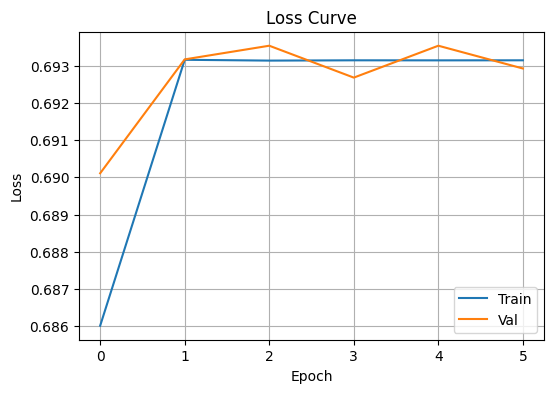

In [5]:
# =========================================
# 5. TEXTCNN MODEL, LOSS, OPTIMIZER, TRAINING
# =========================================

class TextCNN(nn.Module):
    """
    TextCNN with:
      - embedding
      - parallel Conv1D branches (multiple kernel sizes)
      - global max pooling
      - final MLP with Dropout
    """
    def __init__(self,
                 vocab_size: int,
                 emb_dim: int,
                 num_filters: int,
                 kernel_sizes: list[int],
                 mlp_hidden_dim: int,
                 num_classes: int,
                 dropout: float = 0.2,
                 padding_idx: int = 0):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=padding_idx)

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=emb_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        conv_out_dim = num_filters * len(kernel_sizes)
        self.fc1 = nn.Linear(conv_out_dim, mlp_hidden_dim)
        self.fc2 = nn.Linear(mlp_hidden_dim, num_classes)
        self.drop = nn.Dropout(dropout)
        self.act  = nn.ReLU()

    def forward(self, x):
        emb = self.embedding(x)        #[B, T, E]
        emb = emb.transpose(1, 2)      #[B, E, T]

        pooled_outputs = []
        for conv in self.convs:
            h = self.act(conv(emb))    #[B, F, T']
            p = torch.amax(h, dim=2)   #[B, F]
            pooled_outputs.append(p)

        feat = torch.cat(pooled_outputs, dim=1)  #[B, F * n_kernels]
        h = self.drop(self.act(self.fc1(feat)))
        h = self.drop(h)
        logits = self.fc2(h)
        return logits


# --------------------
# LOSS (with label smoothing) WITHOUT class weights (forced).
# --------------------
cnt = Counter(full_train.labels)
tot = len(full_train)
imbalance = abs(cnt[0] - cnt[1]) / max(1, tot)
print("[LOG] Train distribution:", cnt, "imbalance=", imbalance)

#Force standard CrossEntropy with label smoothing,
#without class weights (to avoid pushing TOO much toward GenAI).
loss_fn = nn.CrossEntropyLoss()
print("[LOG] Use CrossEntropyLoss WITHOUT class weights")

# --------------------
# INSTANTIATE MODEL, OPTIMIZER, SCHEDULER
# --------------------
model = TextCNN(
    vocab_size=len(vocab),
    emb_dim=global_var["embedding_dim"],
    num_filters=global_var["cnn_num_filters"],
    kernel_sizes=global_var["cnn_kernel_sizes"],
    mlp_hidden_dim=global_var["mlp_hidden_dim"],
    num_classes=global_var["output_dim"],
    dropout=global_var["dropout"],
    padding_idx=0
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=global_var["learning_rate"],
    weight_decay=global_var["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

# --------------------
# TRAINING FUNCTION WITH AMP, SCHEDULER, EARLY STOPPING
# --------------------
def train_amp(model, train_loader, val_loader, epochs, patience=5):
    """
    Training loop with:
      - AMP (automatic mixed precision)
      - gradient clipping
      - ReduceLROnPlateau scheduler
      - early stopping based on val loss
    """
    scaler = GradScaler('cuda', enabled=(device.type == "cuda"))
    history = {"train": [], "val": []}
    best_val = math.inf
    best_state = None
    bad_epochs = 0

    try:
        if hasattr(torch, "compile"):
            model = torch.compile(model)
    except Exception:
        pass

    for ep in range(epochs):
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, unit="batch", desc=f"Epoch {ep+1}/{epochs} [train]")
        for bx, by in pbar:
            bx = bx.to(device, non_blocking=True)
            by = by.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            #FIX: no device_type for autocast (you are using torch.amp.autocast).
            with autocast('cuda', enabled=(device.type == "cuda")):
                logits = model(bx)
                loss = loss_fn(logits, by)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            pbar.set_postfix(loss=running_loss / (pbar.n + 1))

        # VALIDATION
        model.eval()
        val_loss = 0.0
        #FIX here as well: no device_type
        with torch.inference_mode(), autocast('cuda', enabled=(device.type == "cuda")):
            for bx, by in val_loader:
                bx = bx.to(device, non_blocking=True)
                by = by.to(device, non_blocking=True)
                logits = model(bx)
                val_loss += loss_fn(logits, by).item()

        val_loss /= max(1, len(val_loader))
        history["train"].append(running_loss / max(1, len(train_loader)))
        history["val"].append(val_loss)

        print(f"[LOG] Ep{ep+1}: train={history['train'][-1]:.4f} | val={val_loss:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"[LOG] Early stop at epoch {ep+1} (best val={best_val:.4f}).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

# --------------------
# RUN TRAINING
# --------------------
history = train_amp(
    model, train_loader, val_loader,
    epochs=global_var["epochs"],
    patience=global_var["patience"]
)

# --------------------
# LOSS PLOT
# --------------------
plt.figure(figsize=(6, 4))
plt.plot(history["train"], label="Train")
plt.plot(history["val"],   label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# ==================================================
# 6. EVALUATION FUNCTIONS, TEMPERATURE SCALING, THRESHOLD TUNING
# ==================================================

def evaluate_loader(model, loader, label_names=("HUMAN", "GenAI"),
                    temperature=1.0, threshold=None, plot_cm=False, title_suffix=""):
    """
    Evaluates the model on a DataLoader.
    Options:
      - temperature: logit scaling (T) for probability calibration.
      - threshold: manual threshold on the probability of class 1 (if None → argmax).
      - plot_cm: if True, shows a heatmap of the confusion matrix.
    Returns:
      - report: dict in classification_report format (output_dict=True).
      - cm: numpy confusion matrix.
    """
    model.eval()
    y_true, y_pred = [], []

    with torch.inference_mode():
        for bx, by in loader:
            #Forward + temperature scaling.
            logits = model(bx.to(device)) / temperature

            if threshold is None:
                #Standard prediction via argmax over logits.
                pred = logits.argmax(1).cpu().numpy()
            else:
                #Probability of class 1 (GenAI).
                p1 = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
                #Binary prediction via manual threshold.
                pred = (p1 >= threshold).astype(int)

            #Accumulate predictions and true labels.
            y_pred.extend(pred.tolist())
            y_true.extend(by.cpu().numpy().tolist())

    #Classification report (per-class + macro/micro averages).
    report = classification_report(
        y_true, y_pred,
        target_names=list(label_names),
        output_dict=True,
        digits=4
    )

    #Confusion matrix.
    cm = confusion_matrix(y_true, y_pred)

    #Plot confusion matrix if requested.
    if plot_cm:
        plt.figure(figsize=(5, 4))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names
        )
        ttl = "Confusion Matrix" + (f" {title_suffix}" if title_suffix else "")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(ttl)
        plt.tight_layout()
        plt.show()

    return report, cm

def evaluate_csv(model, csv_path, vocab, batch_size=None, n_workers=None,
                 label_names=("HUMAN", "GenAI"), temperature=1.0, threshold=None,
                 plot_cm=False, title_suffix=""):
    """
    Evaluation wrapper that:
      - builds a TextDataset from a CSV
      - builds a DataLoader (no shuffle)
      - calls evaluate_loader
    """
    batch_size = batch_size or global_var["batch_size"]

    #Build dataset with a fixed vocabulary (the TRAIN one).
    ds = TextDataset(csv_path, vocab=vocab)

    #DataLoader for evaluation (no shuffle).
    dl = make_loader(ds, batch_size=batch_size, shuffle=False)

    #Call the generic evaluation function.
    rep, cm = evaluate_loader(
        model, dl, label_names=label_names,
        temperature=temperature, threshold=threshold,
        plot_cm=plot_cm, title_suffix=title_suffix
    )
    return rep, cm, len(ds)

def calibrate_temperature(model, val_loader, device):
    """
    Calibrates the temperature T on the VALIDATION set by minimizing CrossEntropy
    via optimization of logT with L-BFGS.
    """
    model.eval()
    logits_list, labels_list = [], []

    #Accumulate logits and labels over the full VALIDATION set.
    with torch.inference_mode():
        for bx, by in val_loader:
            logits_list.append(model(bx.to(device)))      #[B, C]
            labels_list.append(by.to(device))             #[B]

    #Concatenate across the batch dimension: [N, C] and [N].
    logits = torch.cat(logits_list)
    labels = torch.cat(labels_list)

    #Reference loss for calibration (on unnormalized logits).
    nll = nn.CrossEntropyLoss()

    #logT parameter to ensure T > 0 (T = exp(logT)).
    logT = torch.tensor(0.0, device=device, requires_grad=True)

    #L-BFGS optimizer on the single parameter logT.
    optimizer_T = torch.optim.LBFGS([logT], lr=0.5, max_iter=50)

    def closure():
        optimizer_T.zero_grad()
        T = torch.exp(logT)
        loss = nll(logits / T, labels)
        loss.backward()
        return loss

    #Run L-BFGS iterations.
    optimizer_T.step(closure)

    #Extract the optimal temperature as float.
    T = torch.exp(logT).item()
    print(f"[VAL] Optimal temperature T={T:.3f}")
    return T

def tune_threshold_on_val(model, val_loader, device, temperature=1.0, metric="balanced_accuracy"):
    """
    Runs a grid search over threshold t in [0.05, 0.95] to maximize:
      - balanced_accuracy (default) or
      - macro F1 (if metric='f1_macro')
    on the VALIDATION set, using probabilities calibrated with T.
    """
    model.eval()
    y_true_val, y_prob_val = [], []

    #Compute p(class=1) over the full VALIDATION set.
    with torch.inference_mode():
        for bx, by in val_loader:
            logits = model(bx.to(device)) / temperature
            p1 = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_prob_val.extend(p1.tolist())
            y_true_val.extend(by.numpy().tolist())

    y_true_val = np.array(y_true_val)
    y_prob_val = np.array(y_prob_val)

    best_t, best_score = 0.5, -1.0

    #Grid search over 19 evenly spaced thresholds in [0.05, 0.95].
    for t in np.linspace(0.05, 0.95, 19):
        y_hat = (y_prob_val >= t).astype(int)

        if metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_true_val, y_hat)
        else:
            score = f1_score(y_true_val, y_hat, average="macro")

        if score > best_score:
            best_score, best_t = score, t

    #Final report on VALIDATION for the best threshold.
    y_hat = (y_prob_val >= best_t).astype(int)
    print(
        f"[VAL] Optimal threshold t*={best_t:.2f} "
        f"(bal_acc={balanced_accuracy_score(y_true_val, y_hat):.3f}, "
        f"f1_macro={f1_score(y_true_val, y_hat, average='macro'):.3f}, "
        f"acc={accuracy_score(y_true_val, y_hat):.3f})"
    )

    return best_t

[VAL] Optimal temperature T=0.929
[VAL] Optimal threshold t*=0.05 (bal_acc=0.500, f1_macro=0.385, acc=0.626)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


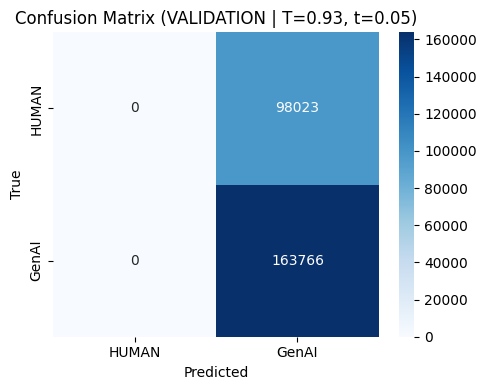


[LOG] Validation on tmp6gg0kb2f.csv — samples: 261789
Accuracy: 0.6256  |  F1 macro: 0.3848  |  Precision macro: 0.3128  |  Recall macro: 0.5000
[CHECK] VALIDATION rows = 261789
[CHECK] TEST rows       = 60


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


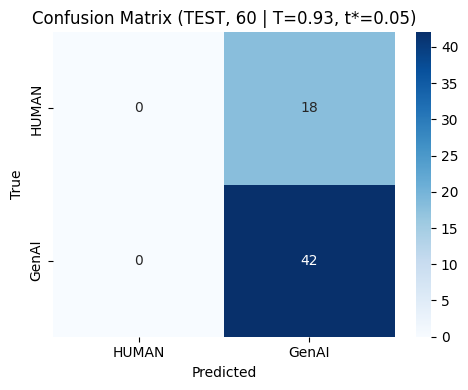


[LOG] Test on tmpv28f19zy.csv — samples: 60
Accuracy: 0.7000  |  F1 macro: 0.4118  |  Precision macro: 0.3500  |  Recall macro: 0.5000
[INFO] TEST — show all 60 rows (errors first). The full file is saved on Drive.



,id,text,true,pred,prob_genai_it,correct
2,1d9f9c17-8260-43fd-8d32-c7570d4e6287,"In terms of written sources in the Medieval period , most of them are from higher - up government sources , such as treaties , speeches from monarchs or tre...",HUMAN,GenAI,"0,5064047",✗
7,026b8a68-9a06-450d-bf45-1b8ff4c2691f,"Carpet-weaving is historically a major traditional profession for the majority of Armenian women, including many Armenian families. Prominent Karabakh carpe...",HUMAN,GenAI,"0,5064047",✗
12,fd8959f1-293c-4dc1-87de-39e824225cb6,"I love spicy food pretty much because I enjoy the taste . I would n't enjoy something so hot that I actually consider it "" pain "" though , I want to break a...",HUMAN,GenAI,"0,5064047",✗
18,b816ff7b-c182-4a07-9fef-e62dbaf08858,"Well in terms of governing , the economy is integral , but its not the only thing that matters . In addition , because the president has economists as advis...",HUMAN,GenAI,"0,5064047",✗
20,3709e3cc-77b8-4913-ae61-24544e061143,"We hadn't been to Macayo's for awhile and I remember them being better than last night. Both of our foods, bean burro and chimi, were completely tasteless. ...",HUMAN,GenAI,"0,5064047",✗
26,15459941-6257-43d9-a419-bd7e76de1785,"José Mariano de la Cruz de la Riva Agüero y Sánchez Boquete, Marquess of Montealegre de Aulestia (3 May 1783 – 21 May 1858) was a soldier, politician, and h...",HUMAN,GenAI,"0,5064047",✗
28,ddf135f8-7062-4ded-99a5-d47552135ecb,In the conservative camp There is this idea that most mainstream news sources tend to side with liberal ideologies . It basically refers to the big news com...,HUMAN,GenAI,"0,5064047",✗
29,ad236fe9-a338-4076-83a5-d43ec5611f74,"The earliest surviving written work on the subject of architecture is De architectura, by the Roman architect Vitruvius in the early 1st century AD. Accordi...",HUMAN,GenAI,"0,5064047",✗
33,da9586a0-d52e-47d5-9ffe-dcdf0d0e6520,"This study points to a similar mode of action for the two viral proteins, suggesting that anti-viral strategy that targets the viral-induced membrane fusion...",HUMAN,GenAI,"0,5064047",✗
34,1129f2ab-b279-4093-bfb4-b9ec5f2077cc,"Individual hair follicles determine the attributes of each strand of hair , aberrations of conditions ( increased testosterone at that area , UV damage , et...",HUMAN,GenAI,"0,5064047",✗


[LOG] Full file saved to: /content/drive/MyDrive/TESI-Classificazione/MIO/test_predictions_dtEN_T0.93_t0.05.csv

[INFO] Total errors (TEST): 18



,id,text,true,pred,prob_genai_it,correct
2,1d9f9c17-8260-43fd-8d32-c7570d4e6287,"In terms of written sources in the Medieval period , most of them are from higher - up government sources , such as treaties , speeches from monarchs or tre...",HUMAN,GenAI,"0,5064047",✗
7,026b8a68-9a06-450d-bf45-1b8ff4c2691f,"Carpet-weaving is historically a major traditional profession for the majority of Armenian women, including many Armenian families. Prominent Karabakh carpe...",HUMAN,GenAI,"0,5064047",✗
12,fd8959f1-293c-4dc1-87de-39e824225cb6,"I love spicy food pretty much because I enjoy the taste . I would n't enjoy something so hot that I actually consider it "" pain "" though , I want to break a...",HUMAN,GenAI,"0,5064047",✗
18,b816ff7b-c182-4a07-9fef-e62dbaf08858,"Well in terms of governing , the economy is integral , but its not the only thing that matters . In addition , because the president has economists as advis...",HUMAN,GenAI,"0,5064047",✗
20,3709e3cc-77b8-4913-ae61-24544e061143,"We hadn't been to Macayo's for awhile and I remember them being better than last night. Both of our foods, bean burro and chimi, were completely tasteless. ...",HUMAN,GenAI,"0,5064047",✗
26,15459941-6257-43d9-a419-bd7e76de1785,"José Mariano de la Cruz de la Riva Agüero y Sánchez Boquete, Marquess of Montealegre de Aulestia (3 May 1783 – 21 May 1858) was a soldier, politician, and h...",HUMAN,GenAI,"0,5064047",✗
28,ddf135f8-7062-4ded-99a5-d47552135ecb,In the conservative camp There is this idea that most mainstream news sources tend to side with liberal ideologies . It basically refers to the big news com...,HUMAN,GenAI,"0,5064047",✗
29,ad236fe9-a338-4076-83a5-d43ec5611f74,"The earliest surviving written work on the subject of architecture is De architectura, by the Roman architect Vitruvius in the early 1st century AD. Accordi...",HUMAN,GenAI,"0,5064047",✗
33,da9586a0-d52e-47d5-9ffe-dcdf0d0e6520,"This study points to a similar mode of action for the two viral proteins, suggesting that anti-viral strategy that targets the viral-induced membrane fusion...",HUMAN,GenAI,"0,5064047",✗
34,1129f2ab-b279-4093-bfb4-b9ec5f2077cc,"Individual hair follicles determine the attributes of each strand of hair , aberrations of conditions ( increased testosterone at that area , UV damage , et...",HUMAN,GenAI,"0,5064047",✗


In [7]:
# ==================================================
# 7. VALIDATION CALIBRATION, FINAL EVALUATION, AND TEST CSV SAVING
# ==================================================

#For safety, if for some reason val_loader does not exist, use test_loader as a fallback.
try:
    val_loader
except NameError:
    val_loader = test_loader

# -------- 7.1 Temperature calibration T on VALIDATION --------
T_eval = calibrate_temperature(model, val_loader, device)

# -------- 7.2 Threshold tuning t* on VALIDATION (using T_eval) --------
t_eval_star = tune_threshold_on_val(
    model, val_loader, device,
    temperature=T_eval,
    metric="f1_macro"   #You can switch to "balanced_accuracy" if you prefer.
)

# -------- 7.3 Manual threshold override, if requested --------
#If you want a fixed threshold (e.g., 0.35), just set it in global_var["DECISION_THRESHOLD_OVERRIDE"].
if global_var.get("DECISION_THRESHOLD_OVERRIDE") is not None:
    t_eval_star = float(global_var["DECISION_THRESHOLD_OVERRIDE"])
    print(f"[INFO] Soglia di decisione OVERRIDE applicata: t={t_eval_star:.2f}")

#Vocabulary to use for evaluation (same as train).
vocab_for_eval = base_vocab

# -------- 7.4 Evaluation on VALIDATION (report + CM) --------
rep_val, cm_val, n_val = evaluate_csv(
    model, EVAL_CSV, vocab=vocab_for_eval,
    label_names=("HUMAN", "GenAI"),
    temperature=T_eval, threshold=t_eval_star,
    plot_cm=True, title_suffix=f"(VALIDATION | T={T_eval:.2f}, t={t_eval_star:.2f})"
)

print(f"\n[LOG] Validation on {os.path.basename(EVAL_CSV)} — samples: {n_val}")
print(
    f"Accuracy: {rep_val['accuracy']:.4f}  |  "
    f"F1 macro: {rep_val['macro avg']['f1-score']:.4f}  |  "
    f"Precision macro: {rep_val['macro avg']['precision']:.4f}  |  "
    f"Recall macro: {rep_val['macro avg']['recall']:.4f}"
)

# -------- 7.5 Sanity check: VALIDATION and TEST files exist --------
assert os.path.exists(EVAL_CSV), f"File of VALIDATION not found: {EVAL_CSV}"
assert os.path.exists(TEST_CSV),  f"File of TEST not found: {TEST_CSV}"
print(f"[CHECK] VALIDATION rows = {len(pd.read_csv(EVAL_CSV))}")
print(f"[CHECK] TEST rows       = {len(pd.read_csv(TEST_CSV))}")

# -------- 7.6 FINAL evaluation on TEST (60) with CM & report --------
rep_test, cm_test, n_test = evaluate_csv(
    model, TEST_CSV, vocab=vocab_for_eval,
    label_names=("HUMAN", "GenAI"),
    temperature=T_eval, threshold=t_eval_star,
    plot_cm=True, title_suffix=f"(TEST, 60 | T={T_eval:.2f}, t*={t_eval_star:.2f})"
)

print(f"\n[LOG] Test on {os.path.basename(TEST_CSV)} — samples: {n_test}")
print(
    f"Accuracy: {rep_test['accuracy']:.4f}  |  "
    f"F1 macro: {rep_test['macro avg']['f1-score']:.4f}  |  "
    f"Precision macro: {rep_test['macro avg']['precision']:.4f}  |  "
    f"Recall macro: {rep_test['macro avg']['recall']:.4f}"
)

# ==================================================
# 7.7 BUILD A DETAILED TEST TABLE + SAVE CSV
# ==================================================

#Re-create a TEST DataLoader that reuses the TRAIN vocabulary.
test_ds = TextDataset(TEST_CSV, vocab=vocab_for_eval)
test_dl = make_loader(test_ds, batch_size=global_var["batch_size"], shuffle=False)

probs, preds = [], []
model.eval()
with torch.inference_mode():
    for bx, _ in test_dl:
        #Logits with temperature T_eval.
        logits = model(bx.to(device)) / T_eval
        #Probability of the GenAI class (id=1).
        p1 = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        probs.extend(p1.tolist())
        preds.extend((p1 >= t_eval_star).astype(int).tolist())

#Load the source CSV to add id/topic/text.
df_src = pd.read_csv(TEST_CSV)

#Numeric -> textual label mapping.
map_lab = {0: "HUMAN", 1: "GenAI"}

#Build the output DataFrame with key columns.
df_out = pd.DataFrame({
    **({"id": df_src["id"]} if "id" in df_src.columns else {}),
    **({"topic": df_src["topic"]} if "topic" in df_src.columns else {}),
    "text": df_src["text"].astype(str),
    "true_id": df_src["label"].astype(int),
    "pred_id": np.array(preds, dtype=int),
    "prob_genai": np.array(probs, dtype=np.float64)
})

#Derived textual columns.
df_out["true"] = df_out["true_id"].map(map_lab)
df_out["pred"] = df_out["pred_id"].map(map_lab)
df_out["correct"] = np.where(df_out["true_id"] == df_out["pred_id"], "✓", "✗")

#Probability formatting in Italian style (comma as decimal separator).
def format_it(x: float, decimals: int = 7) -> str:
    return f"{float(x):.{decimals}f}".replace('.', ',')

df_out["prob_genai_it"] = df_out["prob_genai"].map(lambda v: format_it(v, 7))

#Sort rows: errors first, then by prob_genai descending.
df_view = df_out.copy()
df_view["err_rank"] = (df_view["correct"] == "✓").astype(int)  # 0 = errore, 1 = corretto.
df_view = df_view.sort_values(
    ["err_rank", "prob_genai"],
    ascending=[True, False]
).drop(columns=["err_rank"])

#Display settings to show everything in Colab.
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 1000)

#Select columns to display (id/topic if they exist).
display_cols = [c for c in ["id", "topic"] if c in df_view.columns] \
             + ["text", "true", "pred", "prob_genai_it", "correct"]

print(f"[INFO] TEST — show all {len(df_view)} rows (errors first). The full file is saved on Drive.\n")
display(df_view[display_cols])

#Save a versioned CSV with T and t* (keep the original naming 'art&mh' for compatibility).
os.makedirs(BASE, exist_ok=True)
fname = f"test_predictions_dtEN_T{T_eval:.2f}_t{t_eval_star:.2f}.csv"
save_path = os.path.join(BASE, fname)
df_view.to_csv(save_path, index=False, encoding="utf-8", sep=';', decimal=',')

print("[LOG] File completo salvato in:", save_path)

#Second panel: errors only (if any).
df_errors = df_view[df_view["correct"] == "✗"][display_cols]
print(f"\n[INFO] Errori totali (TEST): {len(df_errors)}\n")
display(df_errors)